In [194]:
import numpy as np

class TrapezoidalProfile:
    def __init__(self, maxspeed, maxaccel, dt) -> None:

        self.a = maxaccel
        self.v = maxspeed
        self.ta = self.v/self.a
        self.xdes = 0
        self.dt = dt
        self.direction = 1
        self.xdot = 0
        self.prev_cmd = 0
        self.elapsed_time = 0
        self.time_to_stop = 0
        self.prev_speed = 0


    def set_position_cmd(self, xdes,t):
        self.prev_cmd = self.xdes
        self.xdes = xdes
        if self.v**2/self.a <= xdes:
            self.T = (self.a*self.xdes + self.v**2)/(self.a*self.v) #this is only valid if v^2/a <= xdes, which is not always the case with early stopping.
        else:
            # https://www.desmos.com/calculator/uxouxiwxqu
            self.T = np.sqrt(4*self.xdes/self.a) 

        print(f"replanning at time {t}")
        print(f"Final T is now {self.T}")
        print(f"self.prev_speed: {self.prev_speed}")

        #set elapsed time to appropriate value.
        # self.elapsed_time = 0

    def calc_velocity(self, xdes, t):
        # print(f'\nTimestep: {t}')
        if self.xdes != xdes:
            self.set_position_cmd(xdes,t)

        distanceToGo = self.xdes - x
        distanceToStop = self.prev_speed*self.prev_speed/(2*self.a)

        if np.abs(distanceToGo) < 1e-6 and distanceToStop < 1e-6:
            #we are at the target and its time to stop
            speed = 0
            return speed 
        
        if distanceToGo > 0:
            # we are below the target

            #we need to go up from here, maybe decelerate now
            if

        self.time_to_stop = self.prev_speed/self.a

        if self.T - self.elapsed_time <= self.time_to_stop and self.elapsed_time <= self.T:
            #if time remaining is less than time to stop, then we need to start braking, but only if we are not already finished
            # print("braking")
            # print(f"time needed to stop: {self.time_to_stop}")
            speed = self.a*(self.T - self.elapsed_time)

        elif 0 <= self.elapsed_time and self.elapsed_time <= self.ta:
            #if we are in the first part of the profile, we are accelerating
            speed = self.a*self.elapsed_time

        elif self.ta < self.elapsed_time and self.elapsed_time <= self.T-self.ta:
            #if we are in the middle part of the profile, we are at max speed
            speed = self.v

        elif self.T-self.ta < self.elapsed_time and self.elapsed_time <= self.T:
            #if we are in the last part of the profile, we are decelerating
            speed = self.a*(self.T-self.elapsed_time)

        elif self.elapsed_time > self.T:
            #if we are past the end of the profile, we are at the goal and shouldn't move.
            print("reached goal")
            speed = 0

        self.elapsed_time += self.dt

        self.prev_speed = speed
        return speed
    
#todo: need to handle changing direction, goal changes to behind you.
#done: stopping before hitting max velocity
#done: extending goal farther during ramp or constant velocity
#todo: need to handle changing goal during deceleration


dt = 1e-2
tspan = np.arange(0,5,dt)
vhist = []
xhist = []
xdes = 2
vmax = 1
amax = 1
x = 0


prof = TrapezoidalProfile(vmax, amax, dt)

for t in tspan:
    if t >= 2.5:
        xdes = 2.5 #limits to what I can achieve with my current vmax and amax v^2/a <= xdes
        
    v = prof.calc_velocity(xdes, t)
    x = x + v*dt
    vhist.append(v)
    xhist.append(x)



replanning at time 0.0
Final T is now 3.0
self.prev_speed: 0
replanning at time 2.5
Final T is now 3.5
self.prev_speed: 0.5100000000000091
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
reached goal
rea

2.377500000000022


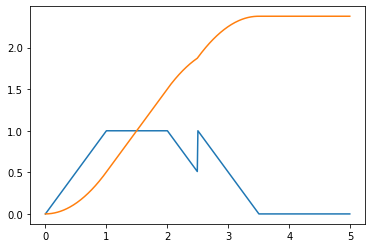

In [195]:
import matplotlib.pyplot as plt
plt.plot(tspan, vhist)
plt.plot(tspan, xhist)
print(xhist[-1])

In [84]:
import numpy as np

class TrapezoidalProfile:
    def __init__(self, maxspeed, maxaccel) -> None:
        assert maxspeed**2/maxaccel <= 1, "vmax^2/amax must be geq than 1"

        self.a = maxaccel
        self.v = maxspeed
        self.xdes = 0
        self.pos_offset = 0
        self.v0 = 0
        self.prev_xdes = 0




    def reset_planning(self, xdes, x, v):
        print("resetting")
        #when position command gets changed, set v0 to current velocity and position offset to current position
        self.pos_offset = x
        self.v0 = v #I think this needs to be current velocity (from the state)
        self.xdes = xdes
        self.distance_to_saturation = (self.v**2 - self.v0**2)/(2*self.a)
        self.distance_to_stop = self.v**2/(2*self.a) #!technically dependednt on current velocity

    def calc_velocity(self, xdes, x, v, t):
        if self.xdes != xdes:
            self.reset_planning(xdes, x, v)

        if self.pos_offset <= x and x <= self.distance_to_saturation + self.pos_offset:
            #accelerate
            speed = np.sqrt(self.v0**2 + 2*self.a*(x-self.pos_offset))

        elif self.distance_to_saturation + self.pos_offset < x and x <= self.xdes - self.distance_to_stop:
            #coast
            speed = self.v
        elif self.xdes - self.distance_to_stop < x and x <= self.xdes:
            #decelerate
            speed = np.sqrt(self.v**2 - 2*self.a*(x-(self.xdes-self.distance_to_stop)))
        else:
            speed = 0
        
        return speed
    
dt = 1e-2 
tspan = np.arange(0,5,dt)
vhist = []
xhist = []
xdes = 3
vmax = 1
amax = 1
x = 1
prev_x = 0
prev_v = 0

#!this has a problem starting at 0. 0 position means 0 velocity, so it will never start moving


prof = TrapezoidalProfile(vmax, amax)

for t in tspan:
    v = prof.calc_velocity(xdes, prev_x, prev_v, t)
    x = x + v*dt
    vhist.append(v)
    xhist.append(x)
    prev_x = x
    prev_v = v



resetting


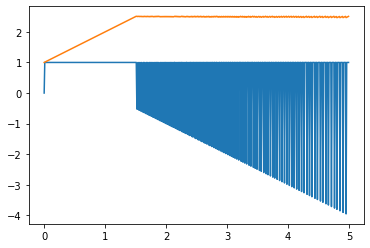

In [85]:
import matplotlib.pyplot as plt
plt.plot(tspan, vhist)
plt.plot(tspan, xhist)

In [200]:
#accelstepper library ported to python

class AccelStepper:
    def __init__(self):
        self._currentPos = 0
        self._targetPos = 0
        self._speed = 0.0
        self._maxSpeed = 0.0
        self._acceleration = 0.0
        self._sqrt_twoa = 1.0
        self._stepInterval = 0
        self._minPulseWidth = 1
        self._enablePin = 0xff
        self._lastStepTime = 0
        self._enableInverted = False

        # NEW
        self._n = 0
        self._c0 = 0.0
        self._cn = 0.0
        self._cmin = 1.0
        self._direction = 1

        self._pinInverted = [0] * 4
        # Some reasonable default
        # self.setAcceleration(1)
        self._acceleration = 1
        # self.setMaxSpeed(1)

    def run(self):
        pass

    def distanceToGo(self):
        return self._targetPos - self._currentPos
    
    def moveTo(self, absolute):
        if self._targetPos != absolute:
            self._targetPos = absolute
            self.computeNewSpeed()
            # compute new n?



    def computeNewSpeed(self):
        distanceTo = self.distanceToGo()  # +ve is clockwise from current location

        stepsToStop = int((self._speed ** 2) / (2.0 * self._acceleration))  # Equation 16

        if distanceTo == 0 and stepsToStop <= 1:
            # We are at the target and it's time to stop
            self._stepInterval = 0
            self._speed = 0.0
            self._n = 0
            return self._stepInterval

        if distanceTo > 0:
            # We are anticlockwise from the target
            # Need to go clockwise from here, maybe decelerate now
            if self._n > 0:
                # Currently accelerating, need to decel now? Or maybe going the wrong way?
                if stepsToStop >= distanceTo or self._direction == 1:
                    self._n = -stepsToStop  # Start deceleration
            elif self._n < 0:
                # Currently decelerating, need to accel again?
                if stepsToStop < distanceTo and self._direction == 0:
                    self._n = -self._n  # Start acceleration
        elif distanceTo < 0:
            # We are clockwise from the target
            # Need to go anticlockwise from here, maybe decelerate
            if self._n > 0:
                # Currently accelerating, need to decel now? Or maybe going the wrong way?
                if stepsToStop >= -distanceTo or self._direction == 0:
                    self._n = -stepsToStop  # Start deceleration
            elif self._n < 0:
                # Currently decelerating, need to accel again?
                if stepsToStop < -distanceTo and self._direction == 1:
                    self._n = -self._n  # Start acceleration

        # Need to accelerate or decelerate
        if self._n == 0:
            # First step from stopped
            self._cn = self._c0
            self._direction = 0 if distanceTo > 0 else 1
        else:
            # Subsequent step. Works for accel (n is +ve) and decel (n is -ve).
            self._cn = self._cn - ((2.0 * self._cn) / ((4.0 * self._n) + 1))  # Equation 13
            self._cn = max(self._cn, self._cmin)

        self._n += 1
        self._stepInterval = self._cn
        self._speed = 1000000.0 / self._cn
        if self._direction == 1:
            self._speed = -self._speed

        # Uncomment the following lines for debugging
        # print(self._speed)
        # print(self._acceleration)
        # print(self._cn)
        # print(self._c0)
        # print(self._n)
        # print(self._stepInterval)
        # print(distanceTo)
        # print(stepsToStop)
        # print("-----")

        # ? do I need an internal step count? Since to mujoco I am only commanding velocities...
        # I could have internal distance
        
        return self._stepInterval
    

stepper = AccelStepper()
stepper.moveTo(100)
stepper.computeNewSpeed()

ZeroDivisionError: float division by zero

5.333333333333334
[-0.47456  1.28    -0.7776   0.2646  -0.04185  0.00243]


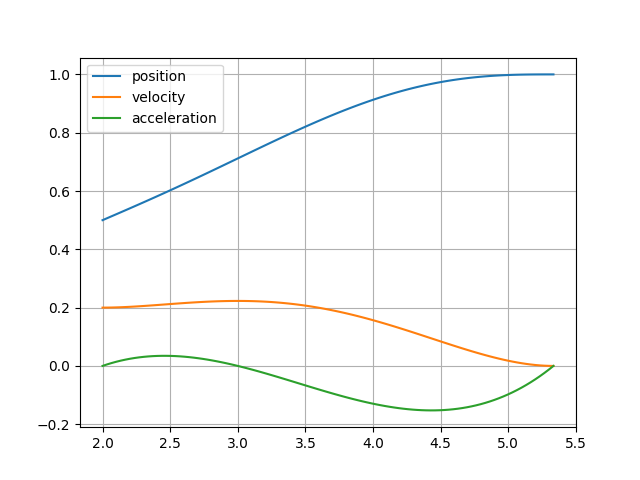

max velocity: 0.2229441927413377
max acceleration: 0.034658801049984644


In [286]:
#quintic polynomial planning for elevator
t0 = 2
v0 = .2

a0 = 0
af = 0

q0 = .5
qf = 1

def plan_traj(t0, v0, a0, q0, qf):
    xtotal = 1.5 
    ttotal = 10 

    avg_vel = xtotal/ttotal #parameter that use passes in

    vf = 0
    af = 0

    # I think q0,v0,a0 all need to come from current state. 
    #qpos, qvel, qacc are all in mjData

    assert np.abs(qf - q0) <= xtotal, "qf - q0 must be less than than xtotal"
    tf = np.abs((qf - q0))/avg_vel + t0
    print(tf)



    T = np.array([[1, t0, t0**2, t0**3, t0**4, t0**5],
                [0, 1, 2*t0, 3*t0**2, 4*t0**3, 5*t0**4],
                [0, 0, 2, 6*t0, 12*t0**2, 20*t0**3],
                [1, tf, tf**2, tf**3, tf**4, tf**5],
                [0, 1, 2*tf, 3*tf**2, 4*tf**3, 5*tf**4],
                [0, 0, 2, 6*tf, 12*tf**2, 20*tf**3]])
    Q = np.array([q0, v0, a0, qf, vf, af])
    coeffs = np.linalg.solve(T,Q)
    return tf,coeffs

tf, coeffs = plan_traj(t0, v0, a0, q0, qf)
print(coeffs)

#plot the trajectory
t = np.linspace(t0,tf,100)
q = coeffs[0] + coeffs[1]*t + coeffs[2]*t**2 + coeffs[3]*t**3 + coeffs[4]*t**4 + coeffs[5]*t**5
v = coeffs[1] + 2*coeffs[2]*t + 3*coeffs[3]*t**2 + 4*coeffs[4]*t**3 + 5*coeffs[5]*t**4
a = 2*coeffs[2] + 6*coeffs[3]*t + 12*coeffs[4]*t**2 + 20*coeffs[5]*t**3

plt.close('all')
plt.figure()
plt.plot(t,q, label='position')
plt.plot(t,v, label='velocity')
plt.plot(t,a, label='acceleration')
plt.legend()
plt.grid()
plt.show()

# print out max values
print(f"max velocity: {np.max(v)}")
print(f"max acceleration: {np.max(a)}")


In [283]:
%timeit plan_traj(t0, v0, a0, q0, qf)

5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.333333333333334
5.33333333

In [ ]:
def calc_vel_cmd(t, qcmd):
    # qcmd is the desired position
    # t is the current simulation time

    #if qcmd isn't the same as the last qcmd, we need to replan from current sim time and pos,vel,accel cmds.
    #this will generate a new tr